# Get Qiskit version

In [1]:
from qiskit import __version__

print(__version__)

2.5.2


In [2]:
from qiskit.visualization import array_to_latex
import numpy as np

### Vectors 

$$
|0\rangle =
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\qquad
|1\rangle =
\begin{bmatrix}
0 \\
1
\end{bmatrix}
$$

In [3]:
ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

display(array_to_latex(ket0), array_to_latex(ket1)) 

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

# States, measurements, and operations

In [4]:
from qiskit.quantum_info import Statevector

u = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])
v = Statevector([(1+2j)/3, -2/3])
w = Statevector([1/3, 2/3])

In [5]:
display(u.draw("text"))
display(u.draw("latex"))
display(u.draw("latex_source"))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

'\\frac{\\sqrt{2}}{2} |0\\rangle+\\frac{\\sqrt{2}}{2} |1\\rangle'

Verify if a vector is a válid quantum state vector. In other words $\|v\| = 1$.

In [6]:
display(u.is_valid())
display(w.is_valid())
display(v.is_valid())

True

False

True

## Simulating measurements using `Statevector`

In [7]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

Running the `measure` method simulates a standard basis measurement.
It returns the outcome of that measurement, plus the new quantum state vector of the system after the measurement.

In [8]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

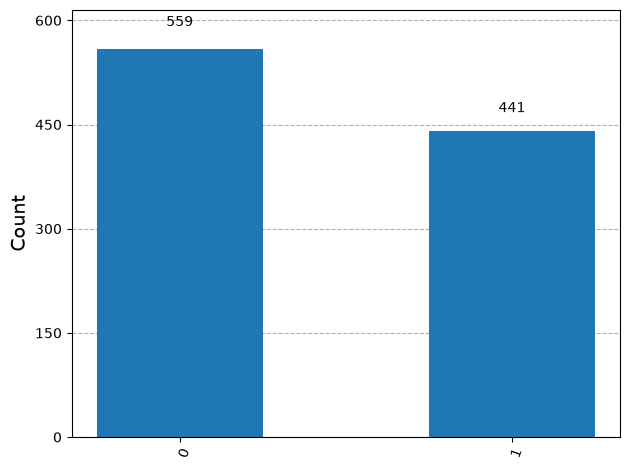

In [9]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

## Perform operations with `Operator` and `Statevector`

Unitary operations can be defined in Qiskit using the `Operator` class, as in the example that follows.

In [10]:
from qiskit.quantum_info import Operator

X = Operator([[0, 1], [1, 0]])
Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / np.sqrt(2), 1 / np.sqrt(2)], [1 / np.sqrt(2), -1 / np.sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / np.sqrt(2)]])

display(X.draw("latex"))
display(Y.draw("latex"))
display(H.draw("latex"))
display(S.draw("latex"))
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can apply a unitary operation to a state vector using the `evolve` method.

In [18]:
v = Statevector([1, 0])


vT = v.evolve(T)
vH = v.evolve(H)
vS = v.evolve(S)
vY = v.evolve(Y)
vX = v.evolve(X)


display(vY.draw("latex"))
display(vX.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### A preview of quantum circuits

In particular, we may define a quantum circuit (which, in this case, will simply be a sequence of unitary operations performed on a single qubit) as follows.

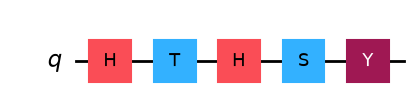

In [22]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

The operations are applied sequentially, starting on the left and ending on the right in the diagram.
A handy way to get the unitary matrix corresponding to this circuit is to use the `from_circuit` method from the `Operator` class.

In [23]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

We can also initialize a starting quantum state vector and then evolve that state according to the sequence of operations described by the circuit.


In [29]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

The following code simulates an experiment where the state obtained from the circuit above is measured with a standard basis measurement 4000 times (using a fresh copy of the state each time).

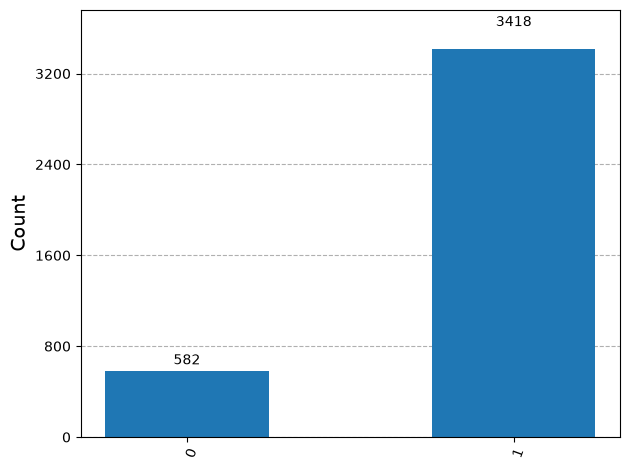

In [30]:
statistics = v.sample_counts(4000)
display(plot_histogram(statistics))

In [38]:
alpha = 0.14644661 - 0.35355339j
beta = -0.35355339 + 0.85355339j

norm_alpha = np.linalg.norm([alpha.real, alpha.imag])
norm_beta = np.linalg.norm([beta.real, beta.imag])

print(norm_alpha**2, norm_beta**2, norm_alpha**2 + norm_beta**2)

0.1464466091609842 0.8535533891609842 0.9999999983219684
